# **Skin Disease classification using Image Processing Models**

Dataset Link: https://www.kaggle.com/datasets/farjanakabirsamanta/skin-cancer-dataset

## **Dataset Downloading**

In [1]:
!pip install -q kaggle

from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [2]:
!kaggle datasets download -d farjanakabirsamanta/skin-cancer-dataset

!unzip skin-cancer-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Skin Cancer/Skin Cancer/ISIC_0029321.jpg  
  inflating: Skin Cancer/Skin Cancer/ISIC_0029322.jpg  
  inflating: Skin Cancer/Skin Cancer/ISIC_0029323.jpg  
  inflating: Skin Cancer/Skin Cancer/ISIC_0029324.jpg  
  inflating: Skin Cancer/Skin Cancer/ISIC_0029325.jpg  
  inflating: Skin Cancer/Skin Cancer/ISIC_0029326.jpg  
  inflating: Skin Cancer/Skin Cancer/ISIC_0029327.jpg  
  inflating: Skin Cancer/Skin Cancer/ISIC_0029328.jpg  
  inflating: Skin Cancer/Skin Cancer/ISIC_0029329.jpg  
  inflating: Skin Cancer/Skin Cancer/ISIC_0029330.jpg  
  inflating: Skin Cancer/Skin Cancer/ISIC_0029331.jpg  
  inflating: Skin Cancer/Skin Cancer/ISIC_0029332.jpg  
  inflating: Skin Cancer/Skin Cancer/ISIC_0029333.jpg  
  inflating: Skin Cancer/Skin Cancer/ISIC_0029334.jpg  
  inflating: Skin Cancer/Skin Cancer/ISIC_0029335.jpg  
  inflating: Skin Cancer/Skin Cancer/ISIC_0029336.jpg  
  inflating: Skin Cancer/Skin Cancer/ISIC_0029337.jpg

**Libraries**

In [3]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tensorflow as tf

In [4]:
warnings.filterwarnings('ignore')

**CSV File**

In [5]:
data_root = "./Skin Cancer/Skin Cancer"

In [6]:
mapping_csv = pd.read_csv("HAM10000_metadata.csv")
mapping_csv.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [7]:
mapping_csv.shape

(10015, 7)

In [8]:
mapping_csv['dx'].value_counts()

,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


## **CSV Preprocessing**

In [9]:
df_filtered = mapping_csv[mapping_csv['dx'].isin(['nv', 'mel', 'bkl'])]
df_filtered['dx'].value_counts()

,count
dx,
nv,6705
mel,1113
bkl,1099


In [10]:
# Taking only 1100 images of 'nv'
df_nv = df_filtered[df_filtered['dx'] == 'nv'].sample(n=1100, random_state=42)

# Take all 'mel' and 'bkl'
df_mel = df_filtered[df_filtered['dx'] == 'mel']
df_bkl = df_filtered[df_filtered['dx'] == 'bkl']

# Combine them
final_df = pd.concat([df_nv, df_mel, df_bkl]).reset_index(drop=True)

# Verify counts
final_df['dx'].value_counts()

,count
dx,
mel,1113
nv,1100
bkl,1099


In [11]:
counts_df = final_df['dx'].value_counts().rename_axis('dx').reset_index(name='count')

print(counts_df)

    dx  count
0  mel   1113
1   nv   1100
2  bkl   1099


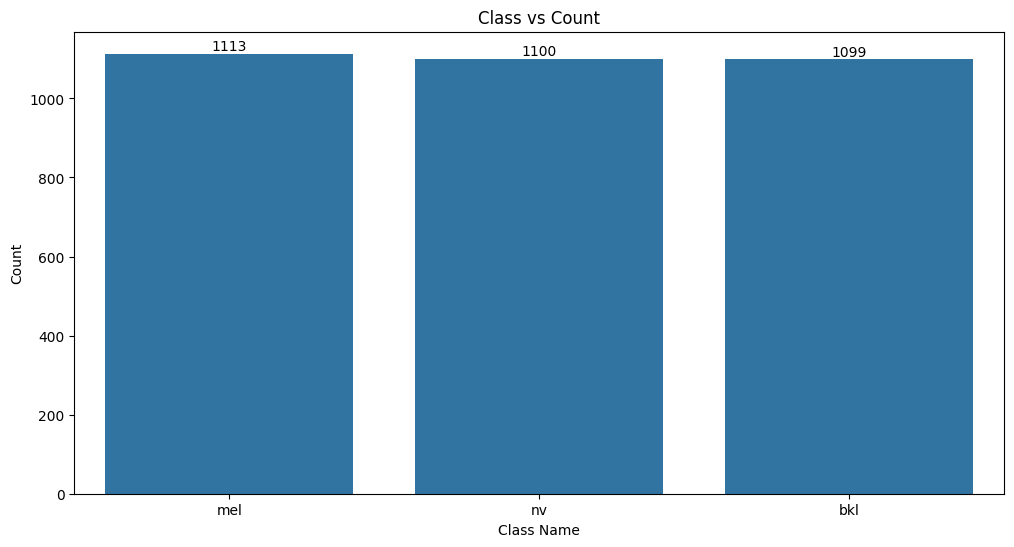

In [12]:
ax = plt.figure(figsize=(12, 6))

ax = sns.barplot(counts_df, x=counts_df['dx'].values, y=counts_df['count'].values)
ax.bar_label(ax.containers[0], fontsize=10)
plt.xlabel("Class Name")
plt.ylabel("Count")
plt.title("Class vs Count")
plt.show()

In [13]:
final_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0003697,ISIC_0025438,nv,follow_up,40.0,male,back
1,HAM_0000217,ISIC_0029881,nv,histo,40.0,male,chest
2,HAM_0003344,ISIC_0026399,nv,follow_up,35.0,female,abdomen
3,HAM_0006028,ISIC_0032189,nv,histo,40.0,male,chest
4,HAM_0000162,ISIC_0026609,nv,follow_up,40.0,female,back


In [14]:
final_df = final_df[['image_id', 'dx']]
final_df.head()

,image_id,dx
0,ISIC_0025438,nv
1,ISIC_0029881,nv
2,ISIC_0026399,nv
3,ISIC_0032189,nv
4,ISIC_0026609,nv


In [15]:
# Create lists for each class
mel_images = (final_df[final_df['dx'] == 'mel']['image_id'] + '.jpg').tolist()
nv_images  = (final_df[final_df['dx'] == 'nv']['image_id'] + '.jpg').tolist()
bkl_images = (final_df[final_df['dx'] == 'bkl']['image_id'] + '.jpg').tolist()

# Check
print(len(mel_images), len(nv_images), len(bkl_images))

1113 1100 1099


## **Image Preprocessing**

#### **Moving images based on classes from Images folder (dataset/Skin Cancer) to (intermediate)**

In [16]:
source_dir = data_root

dest_dir = "intermediate data"

os.makedirs(dest_dir, exist_ok=True)

# Class folders
folders = {
    "melanoma": mel_images,
    "melanocytic nevi": nv_images,
    "benign keratosis": bkl_images
}

for folder_name, image_list in folders.items():

    # Create class folder
    target_dir = os.path.join(dest_dir, folder_name)
    os.makedirs(target_dir, exist_ok=True)

    # Move images
    for img_name in image_list:
        src_path = os.path.join(source_dir, img_name)
        dst_path = os.path.join(target_dir, img_name)

        if os.path.exists(src_path):
            shutil.copy2(src_path, dst_path)   # change to move() for moving from source dir
        else:
            print(f"Missing file: {img_name}")

print("All images moved successfully.")

All images moved successfully.


**Count of images in intermediate class-wise**

In [17]:
nv_images_dir = os.path.join(dest_dir,"melanocytic nevi")
mel_images_dir = os.path.join(dest_dir,"melanoma")
bkl_images_dir = os.path.join(dest_dir, "benign keratosis")
print('Total Melanocytic Nevi images are: ', len(os.listdir(nv_images_dir)))
print('Total Melanoma images are: ', len(os.listdir(mel_images_dir)))
print('Total Benign Keratosis images are: ', len(os.listdir(bkl_images_dir)))

Total Melanocytic Nevi images are:  1100
Total Melanoma images are:  1113
Total Benign Keratosis images are:  1099


#### **Sample Data Visualization**

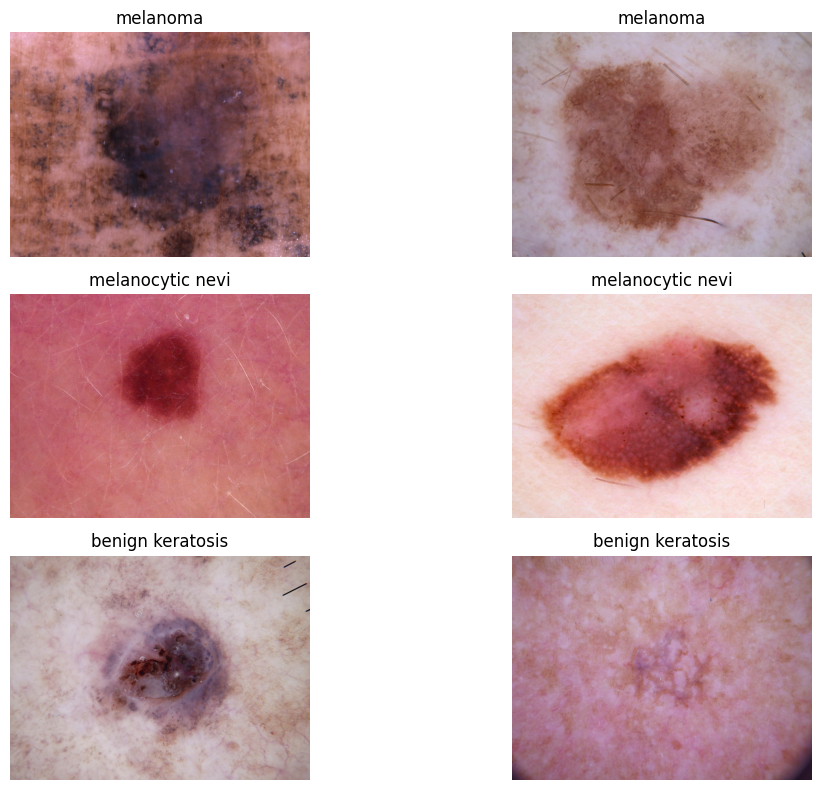

In [18]:
import random
from PIL import Image

# Base directory
base_dir = "intermediate data"

classes = ["melanoma", "melanocytic nevi", "benign keratosis"]

plt.figure(figsize=(12, 8))

plot_index = 1

for class_name in classes:
    class_path = os.path.join(base_dir, class_name)

    # Randomly pick 2 images
    images = random.sample(os.listdir(class_path), 2)

    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        plt.subplot(3, 2, plot_index)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()

#### **Train, Test and Validation Split**

In [19]:
# Source and Target
source_base = "intermediate data"
target_base = "final data"

classes = ["melanoma", "melanocytic nevi", "benign keratosis"]
splits = ["train", "val", "test"]

# Create folder structure
for split in splits:
    for class_name in classes:
        os.makedirs(os.path.join(target_base, split, class_name), exist_ok=True)

# Split ratio
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for class_name in classes:

    class_path = os.path.join(source_base, class_name)
    images = os.listdir(class_path)

    random.shuffle(images)

    total = len(images)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    # Function to move images
    def move_images(image_list, split_name):
        for img in image_list:
            src = os.path.join(class_path, img)
            dst = os.path.join(target_base, split_name, class_name, img)
            shutil.move(src, dst)   # use copy2 if you want to remove from intermediate data

    move_images(train_imgs, "train")
    move_images(val_imgs, "val")
    move_images(test_imgs, "test")

print("Dataset successfully split into train/val/test.")

Dataset successfully split into train/val/test.


**Train Images Count**

In [20]:
final_data_root = "final data"

In [21]:
nv_train_images = os.path.join(final_data_root,"train/melanocytic nevi")
mel_train_images = os.path.join(final_data_root,"train/melanoma")
bkl_train_images = os.path.join(final_data_root, "train/benign keratosis")
print('Total Melanocytic Nevi images for training are: ', len(os.listdir(nv_train_images)))
print('Total Melanoma images for training are: ', len(os.listdir(mel_train_images)))
print('Total Benign Keratosis images for training are: ', len(os.listdir(bkl_train_images)))

Total Melanocytic Nevi images for training are:  770
Total Melanoma images for training are:  779
Total Benign Keratosis images for training are:  769


**Test Images Count**

In [22]:
nv_test_images = os.path.join(final_data_root,"test/melanocytic nevi")
mel_test_images = os.path.join(final_data_root,"test/melanoma")
bkl_test_images = os.path.join(final_data_root, "test/benign keratosis")
print('Total Melanocytic Nevi images for testing are: ', len(os.listdir(nv_test_images)))
print('Total Melanoma images for testing are: ', len(os.listdir(mel_test_images)))
print('Total Benign Keratosis images for testing are: ', len(os.listdir(bkl_test_images)))

Total Melanocytic Nevi images for testing are:  165
Total Melanoma images for testing are:  168
Total Benign Keratosis images for testing are:  166


**Validation Images Count**

In [23]:
nv_val_images = os.path.join(final_data_root,"val/melanocytic nevi")
mel_val_images = os.path.join(final_data_root,"val/melanoma")
bkl_val_images = os.path.join(final_data_root, "val/benign keratosis")
print('Total Melanocytic Nevi images for validatinging are: ', len(os.listdir(nv_val_images)))
print('Total Melanoma images for validating are: ', len(os.listdir(mel_val_images)))
print('Total Benign Keratosis images for validating are: ', len(os.listdir(bkl_val_images)))

Total Melanocytic Nevi images for validatinging are:  165
Total Melanoma images for validating are:  166
Total Benign Keratosis images for validating are:  164


## **Data Augmentation**

In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [25]:
train_dir = "final data/train"
val_dir = "final data/val"
test_dir = "final data/test"

In [26]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 2318 images belonging to 3 classes.


In [27]:
val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 495 images belonging to 3 classes.
Found 499 images belonging to 3 classes.


## **Model Building**

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import EfficientNetB0


#### **Custom CNN**

In [30]:
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(3, activation='softmax')  # 3 classes
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,339 (84.86 MB)

 Trainable params: 22,245,891 (84.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [31]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.2)
]

In [ ]:
cnn_history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    callbacks=callbacks,
    epochs=15
)

Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 68s 710ms/step - accuracy: 0.4922 - loss: 10.1860 - val_accuracy: 0.3333 - val_loss: 25.0236 - learning_rate: 0.0010
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 45s 617ms/step - accuracy: 0.5289 - loss: 2.6769 - val_accuracy: 0.3313 - val_loss: 34.3193 - learning_rate: 0.0010
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 47s 651ms/step - accuracy: 0.5255 - loss: 1.6105 - val_accuracy: 0.3333 - val_loss: 19.8660 - learning_rate: 0.0010
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 598ms/step - accuracy: 0.5664 - loss: 1.0529 - val_accuracy: 0.3354 - val_loss: 19.2758 - learning_rate: 0.0010
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 603ms/step - accuracy: 0.5690 - loss: 1.0211 - val_accuracy: 0.3333 - val_loss: 17.2187 - learning_rate: 0.0010
Epoch 6/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 603ms/step - accuracy: 0.5858 - loss: 0.9293 - val_accuracy: 0.3818 - val_loss: 8.3390 - learning_rate: 0.0010
Epoch 7/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 601ms/step - accuracy: 0.5794 - lo

#### **MobileNetV2**

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=output)

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
mobilenet_history = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    callbacks=callbacks,
    epochs=15
)

Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.5224 - loss: 1.0454 - val_accuracy: 0.6020 - val_loss: 0.8740 - learning_rate: 0.0010
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 596ms/step - accuracy: 0.6100 - loss: 0.8501 - val_accuracy: 0.6343 - val_loss: 0.8043 - learning_rate: 0.0010
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 596ms/step - accuracy: 0.6165 - loss: 0.8365 - val_accuracy: 0.6606 - val_loss: 0.7808 - learning_rate: 0.0010
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 594ms/step - accuracy: 0.6510 - loss: 0.7845 - val_accuracy: 0.6747 - val_loss: 0.7573 - learning_rate: 2.0000e-04
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 52s 711ms/step - accuracy: 0.6609 - loss: 0.7594 - val_accuracy: 0.6768 - val_loss: 0.7531 - learning_rate: 2.0000e-04
Epoch 6/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 45s 612ms/step - accuracy: 0.6760 - loss: 0.7469 - val_accuracy: 0.6788 - val_loss: 0.7528 - learning_rate: 2.0000e-04
Epoch 7/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 599ms/step - accuracy: 0.6687 

#### **EfficientNetB0**

In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

effnet_model = Model(inputs=base_model.input, outputs=output)

effnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# effnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
effnet_history = effnet_model.fit(
    train_generator,
    validation_data=val_generator,
    callbacks=callbacks,
    epochs=15
)

Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.3348 - loss: 1.5338 - val_accuracy: 0.3313 - val_loss: 1.1052 - learning_rate: 0.0010
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 45s 615ms/step - accuracy: 0.3248 - loss: 1.4017 - val_accuracy: 0.3333 - val_loss: 1.1030 - learning_rate: 0.0010
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 607ms/step - accuracy: 0.3430 - loss: 1.3498 - val_accuracy: 0.3333 - val_loss: 1.0995 - learning_rate: 0.0010
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 604ms/step - accuracy: 0.3404 - loss: 1.2382 - val_accuracy: 0.3333 - val_loss: 1.0991 - learning_rate: 2.0000e-04
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 45s 624ms/step - accuracy: 0.3520 - loss: 1.1699 - val_accuracy: 0.3333 - val_loss: 1.0985 - learning_rate: 2.0000e-04


## **Fine Tuning Models**

#### **MobileNetV2 Fine Tuning**

In [ ]:
# Unfreeze last 30 layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_ft_history = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    callbacks=callbacks,
    epochs=15
)

Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 68s 793ms/step - accuracy: 0.7002 - loss: 0.6808 - val_accuracy: 0.6869 - val_loss: 0.7205 - learning_rate: 1.0000e-05
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 45s 618ms/step - accuracy: 0.6864 - loss: 0.6948 - val_accuracy: 0.6869 - val_loss: 0.7213 - learning_rate: 1.0000e-05
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 47s 639ms/step - accuracy: 0.7079 - loss: 0.6714 - val_accuracy: 0.6970 - val_loss: 0.7215 - learning_rate: 1.0000e-05
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 600ms/step - accuracy: 0.7071 - loss: 0.6889 - val_accuracy: 0.6949 - val_loss: 0.7213 - learning_rate: 2.0000e-06
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 605ms/step - accuracy: 0.6980 - loss: 0.6806 - val_accuracy: 0.6949 - val_loss: 0.7214 - learning_rate: 2.0000e-06


#### **EfficientNetB0 Fine Tuning**

In [ ]:
# Unfreeze top layers
for layer in base_model.layers[-50:]:
    layer.trainable = True

effnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

effnet_ft_history = effnet_model.fit(
    train_generator,
    validation_data=val_generator,
    callbacks=callbacks,
    epochs=15
)

Epoch 1/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.3499 - loss: 1.5206 - val_accuracy: 0.3333 - val_loss: 1.1036 - learning_rate: 1.0000e-05
Epoch 2/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 45s 617ms/step - accuracy: 0.3257 - loss: 1.4668 - val_accuracy: 0.3313 - val_loss: 1.1112 - learning_rate: 1.0000e-05
Epoch 3/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 45s 618ms/step - accuracy: 0.3494 - loss: 1.3904 - val_accuracy: 0.2768 - val_loss: 1.1378 - learning_rate: 1.0000e-05
Epoch 4/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 45s 616ms/step - accuracy: 0.3417 - loss: 1.3548 - val_accuracy: 0.3333 - val_loss: 1.2067 - learning_rate: 2.0000e-06
Epoch 5/15
73/73 ━━━━━━━━━━━━━━━━━━━━ 45s 622ms/step - accuracy: 0.3404 - loss: 1.3554 - val_accuracy: 0.3333 - val_loss: 1.1599 - learning_rate: 2.0000e-06


## **Plots**

**Accuracy Curves**

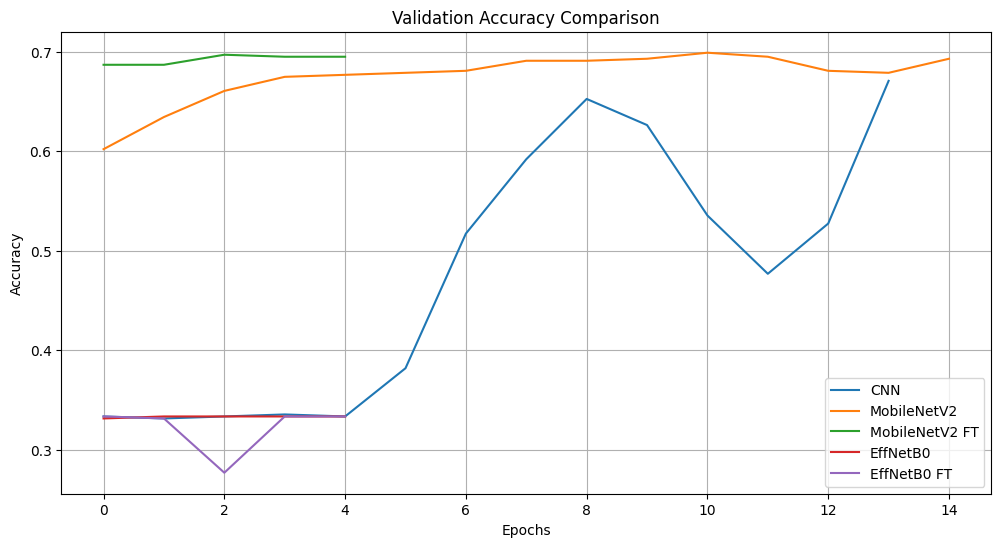

In [ ]:
plt.figure(figsize=(12,6))

# CNN
plt.plot(cnn_history.history['val_accuracy'], label='CNN')

# MobileNet
plt.plot(mobilenet_history.history['val_accuracy'], label='MobileNetV2')
plt.plot(mobilenet_ft_history.history['val_accuracy'], label='MobileNetV2 FT')

# EfficientNet
plt.plot(effnet_history.history['val_accuracy'], label='EffNetB0')
plt.plot(effnet_ft_history.history['val_accuracy'], label='EffNetB0 FT')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

**Loss Curves**

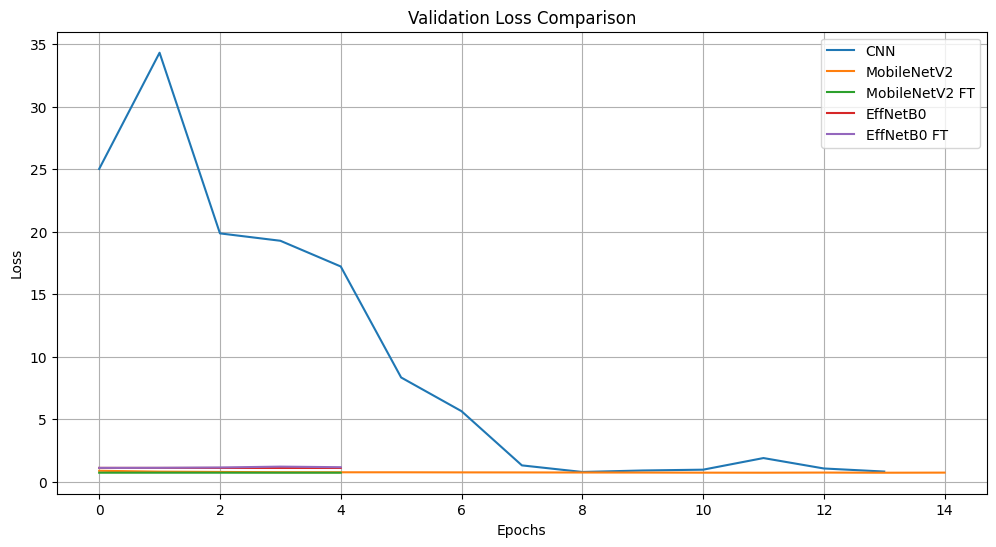

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(cnn_history.history['val_loss'], label='CNN')

plt.plot(mobilenet_history.history['val_loss'], label='MobileNetV2')
plt.plot(mobilenet_ft_history.history['val_loss'], label='MobileNetV2 FT')

plt.plot(effnet_history.history['val_loss'], label='EffNetB0')
plt.plot(effnet_ft_history.history['val_loss'], label='EffNetB0 FT')

plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

## **Metrics**

In [ ]:
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

def get_predictions(model):
    y_pred_probs = model.predict(test_generator)
    y_pred = np.argmax(y_pred_probs, axis=1)
    return y_pred, y_pred_probs

**Evaluation**

In [ ]:
def evaluate_model(model, name):
    y_pred, y_prob = get_predictions(model)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted'),
        "Recall": recall_score(y_true, y_pred, average='weighted'),
        "F1": f1_score(y_true, y_pred, average='weighted')
    }

results = []
results.append(evaluate_model(cnn_model, "CNN"))
results.append(evaluate_model(mobilenet_model, "MobileNetV2"))
results.append(evaluate_model(mobilenet_model, "MobileNetV2 FT"))
results.append(evaluate_model(effnet_model, "EffNetB0"))
results.append(evaluate_model(effnet_model, "EffNetB0 FT"))

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 317ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 260ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 920ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 234ms/step
            Model  Accuracy  Precision    Recall        F1
0             CNN  0.661323   0.694662  0.661323  0.663465
1     MobileNetV2  0.713427   0.723057  0.713427  0.714598
2  MobileNetV2 FT  0.713427   0.723057  0.713427  0.714598
3        EffNetB0  0.330661   0.109337  0.330661  0.164335
4     EffNetB0 FT  0.330661   0.109337  0.330661  0.164335


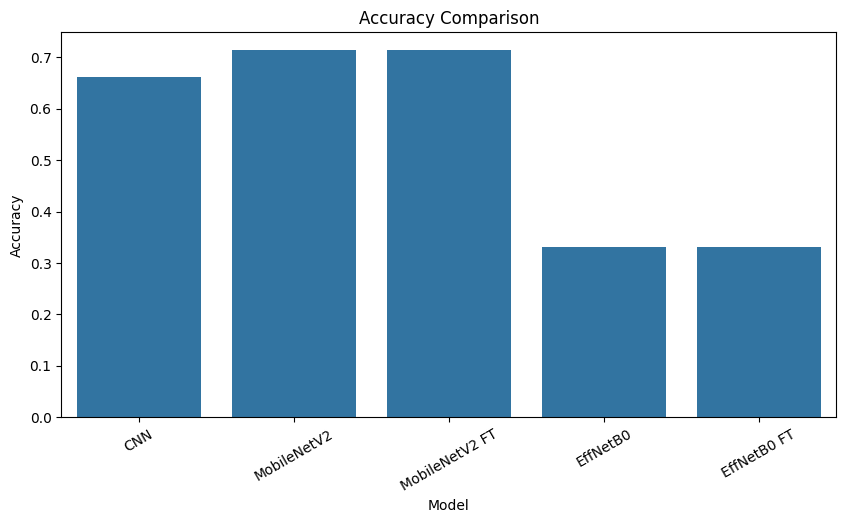

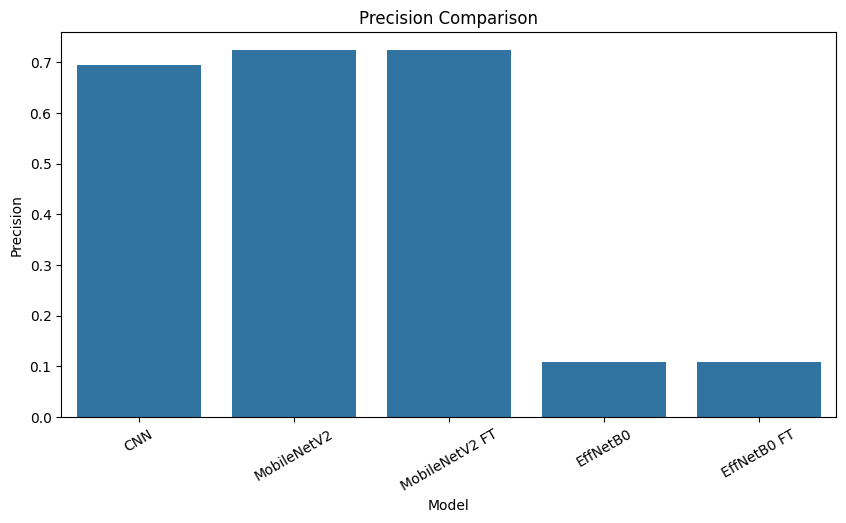

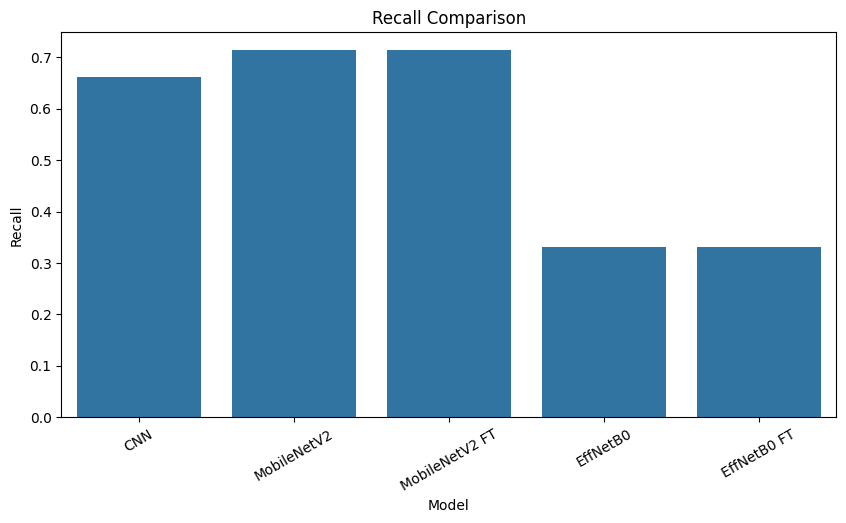

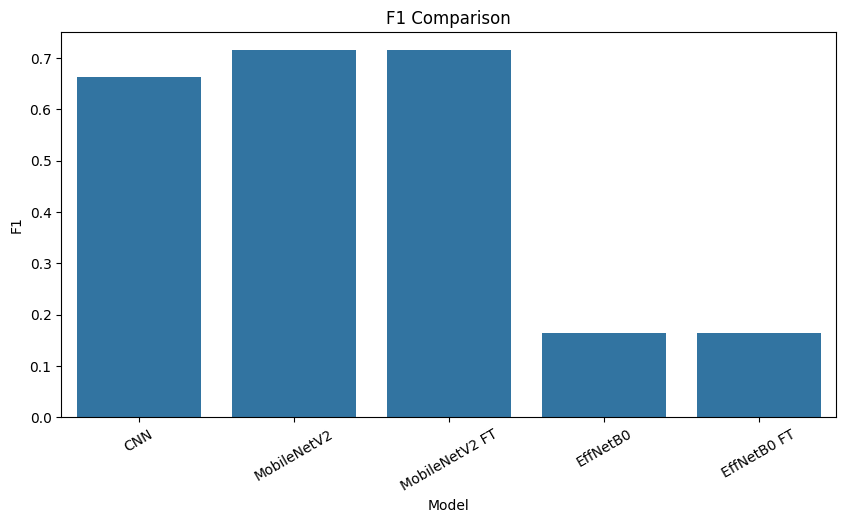

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]

for metric in metrics:
    plt.figure(figsize=(10,5))
    sns.barplot(data=results_df, x="Model", y=metric)
    plt.title(f"{metric} Comparison")
    plt.xticks(rotation=30)
    plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step


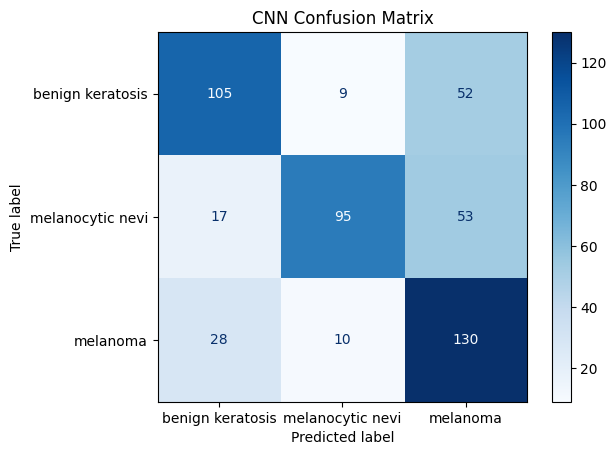

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 202ms/step


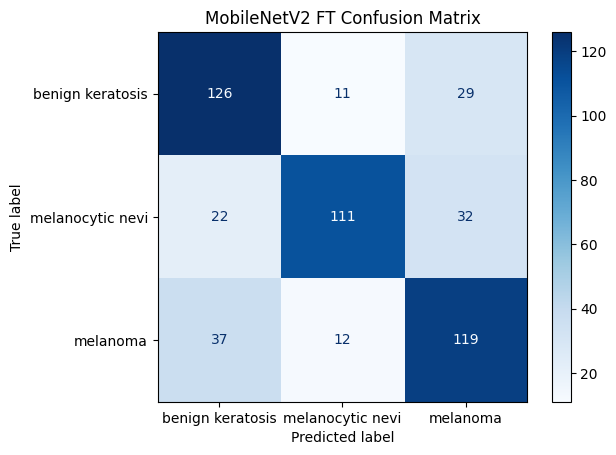

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step


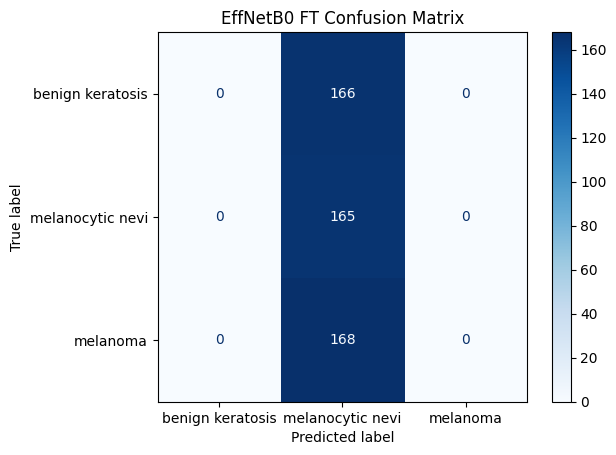

In [ ]:
def plot_conf_matrix(model, title):
    y_pred, _ = get_predictions(model)
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(cm, display_labels=class_labels)
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.show()

plot_conf_matrix(cnn_model, "CNN Confusion Matrix")
plot_conf_matrix(mobilenet_model, "MobileNetV2 FT Confusion Matrix")
plot_conf_matrix(effnet_model, "EffNetB0 FT Confusion Matrix")

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 257ms/step


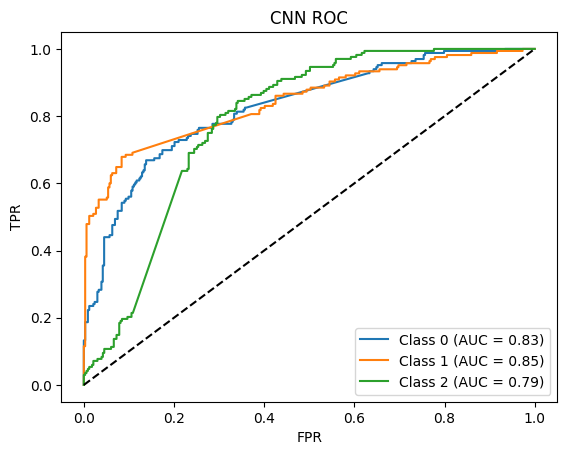

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step


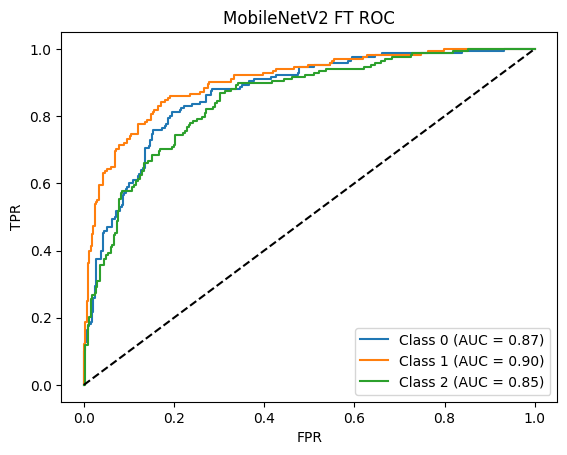

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 200ms/step


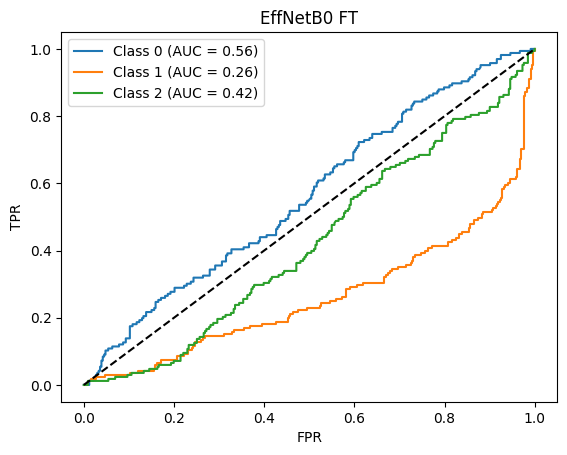

In [ ]:
y_true_bin = label_binarize(y_true, classes=[0,1,2])

def plot_roc(model, title):
    y_pred, y_prob = get_predictions(model)

    for i in range(3):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f"Class {i} (AUC = {auc(fpr, tpr):.2f})")

    plt.plot([0,1],[0,1],'k--')
    plt.title(title)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.show()

plot_roc(cnn_model, "CNN ROC")
plot_roc(mobilenet_model, "MobileNetV2 FT ROC")
plot_roc(effnet_model, "EffNetB0 FT")

## **Grad-CAM**

In [32]:
!pip install opencv-python shap scikit-learn

In [ ]:
import cv2

def grad_cam(model, img_path, layer_name):
    # Load image
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Create grad model
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    # Gradient computation
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    # Global average pooling
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Convert safely to numpy
    heatmap = heatmap.numpy()

    # Normalize
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)

    # Load original image
    img = cv2.imread(img_path)

    # Resize heatmap
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Convert to color
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Superimpose
    superimposed_img = heatmap * 0.4 + img

    # Show
    plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Grad-CAM")
    plt.show()

Selected random image 'ISIC_0033176.jpg' from class 'melanocytic nevi'.


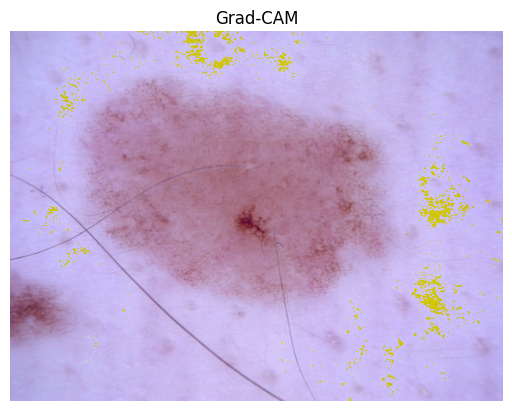

In [ ]:
classes = ["melanoma", "melanocytic nevi", "benign keratosis"]

random_class = random.choice(classes)

random_class_test_dir = os.path.join(final_data_root, "test", random_class)

images_in_random_class = os.listdir(random_class_test_dir)

random_image_name = random.choice(images_in_random_class)
random_image_path = os.path.join(random_class_test_dir, random_image_name)

print(f"Selected random image '{random_image_name}' from class '{random_class}'.")

grad_cam(effnet_model, random_image_path, "top_conv")